<div>

# Assignment 5 Eran Rehani 207823063
# Runge-Kutta and Baseball Trajectories

This notebook builds an adaptive Runge-Kutta solver and then uses it for the baseball trajectory problem.

</div>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Physical constants and baseball parameters in SI units only.
g      = 9.8      # m/s^2
B      = 4.1e-4   # Magnus coefficient
DIST_X = 18.288   # m, pitcher-to-batter distance

# Typical throw parameters, written in SI.
OMEGA = 188.49555921538757      # rad/s
THETA = 0.017453292519943295    # rad

<div>

## Adaptive Runge-Kutta Solver

The function `rk_step` does one Runge-Kutta step. The parameter `order` chooses RK3 or RK4.

For each step size $h$, `rk_adaptive` compares one full step with two half-steps. If the difference is smaller than the requested tolerance, the step is accepted. Otherwise, the step is made smaller and tried again.

After accepting a step, I use Richardson extrapolation,
$$y_{\text{best}}=y_{\text{half}}+\frac{y_{\text{half}}-y_{\text{full}}}{2^p-1},$$
where $p$ is the RK order. This uses both estimates and gives a better final value.

The solver returns the final state, the number of accepted steps, and the number of right-hand-side calls. For the baseball plots it also returns the trajectory.

</div>

In [ ]:
def rk_step(f, t, y, h, order):
    """Single RK step (order 3 or 4). Returns (y_new, n_fcalls)."""
    y = np.asarray(y, dtype=float)
    if order == 3:
        k1 = f(t,         y)
        k2 = f(t + h/2,   y + (h/2)*k1)
        k3 = f(t + h,     y - h*k1 + 2*h*k2)
        return y + (h/6)*(k1 + 4*k2 + k3), 3
    else:  # order == 4
        k1 = f(t,         y)
        k2 = f(t + h/2,   y + (h/2)*k1)
        k3 = f(t + h/2,   y + (h/2)*k2)
        k4 = f(t + h,     y + h*k3)
        return y + (h/6)*(k1 + 2*k2 + 2*k3 + k4), 4


def rk_adaptive(f, t0, y0, t_end, tol, order, return_trajectory=False):
    """Adaptive RK with step-doubling + Richardson extrapolation.

    Returns (y_final, n_steps, n_fcalls)
    or (ts, ys, n_steps, n_fcalls) when return_trajectory=True.
    """
    if order not in (3, 4):
        raise ValueError("order must be 3 or 4")
    t = t0
    y = np.asarray(y0, dtype=float).copy()
    h = (t_end - t0) / 100.0
    n_steps = 0
    n_fcalls = 0
    scale = 2**order - 1 # Richardson denominator

    if return_trajectory:
        ts_list = [t]
        ys_list = [y.copy()]

    while t < t_end:
        h = min(h, t_end - t)

        y_full, nc1 = rk_step(f, t,       y,    h,   order)
        y_mid,  nc2 = rk_step(f, t,       y,    h/2, order)
        y_half, nc3 = rk_step(f, t + h/2, y_mid, h/2, order)
        n_fcalls += nc1 + nc2 + nc3

        err = np.max(np.abs(y_half - y_full))

        if err == 0.0 or err <= tol:
            y = y_half + (y_half - y_full) / scale
            t += h
            n_steps += 1
            if return_trajectory:
                ts_list.append(t)
                ys_list.append(y.copy())
            if err > 0:
                h *= min(2.0, 0.9 * (tol / err) ** (1.0 / (order + 1)))
        else:
            h *= max(0.1, 0.9 * (tol / err) ** (1.0 / (order + 1)))

    if return_trajectory:
        return np.array(ts_list), np.array(ys_list), n_steps, n_fcalls
    return y, n_steps, n_fcalls

<div>

## Check on an ODE with Known Solution

I first test the solver on
$$y'(t)=-y(t),\quad y(0)=1,$$
whose exact solution is $y(t)=e^{-t}$. I integrate to $t=5$, so the exact value is $e^{-5}$.

This checks that the error gets smaller when the requested tolerance is made smaller.

</div>

In [3]:
def decay_rhs(t, y):
    return -y

y_exact = np.exp(-5.0)
print(f"{'Order':>7} {'tol':>10} {'y(5)':>20} {'|error|':>14} {'steps':>7} {'f-calls':>9}")
print("-" * 72)
for order in (3, 4):
    for tol in (1e-3, 1e-6, 1e-9):
        y_num, ns, nf = rk_adaptive(decay_rhs, 0.0, np.array([1.0]), 5.0, tol, order)
        err = abs(y_num[0] - y_exact)
        print(f"{order:>7} {tol:>10.0e} {y_num[0]:>20.14f} {err:>14.4e} {ns:>7d} {nf:>9d}")

  Order        tol                 y(5)        |error|   steps   f-calls
------------------------------------------------------------------------
      3      1e-03     0.00676011752024     2.2171e-05      12       108
      3      1e-06     0.00673798080926     3.3810e-08      46       414
      3      1e-09     0.00673794704052     4.1430e-11     249      2250
      4      1e-03     0.00672943721461     8.5098e-06      10       120
      4      1e-06     0.00673793455122     1.2448e-08      24       288
      4      1e-09     0.00673794698317     1.5913e-11      86      1044


<div>

 The numerical value approaches $e^{-5}=0.006738$ as the tolerance gets smaller. RK4 reaches small error with fewer steps than RK3 for the same tolerance.

</div>

<div>

## Step-Count Benchmark: Sum of Narrow Gaussians

The benchmark equation is
$$\frac{dy}{dx}=\frac{1}{a\sqrt{\pi}}\sum_{i=1}^{5}\exp\left[-\frac{(x-b_i)^2}{a^2}\right],
\quad a=0.1,
\quad b_i\in\{-5,-1,1,4,7\}.$$
The initial condition is $y(-10)=0$, and the goal is $y(10)$.

Each Gaussian has area about $1$, so the answer should be $5$ to very high accuracy. The table uses $5$ as the reference value, as requested.

</div>

In [4]:
_B_VALS = [-5, -1, 1, 4, 7]
_A = 0.1

def gaussian_sum_rhs(x, y):
    total = sum(np.exp(-((x - b) / _A)**2) for b in _B_VALS)
    return np.array([total / (_A * np.sqrt(np.pi))])

TRUE_VAL = 5.0
print(f"{'RK order':>10} {'Req. acc':>12} {'No. steps':>11} {'No. f-calls':>13} {'Rel. error':>13}")
print("-" * 63)
for order in (3, 4):
    for tol in (1e-3, 1e-5, 1e-7, 1e-9):
        y_num, ns, nf = rk_adaptive(gaussian_sum_rhs, -10.0, np.array([0.0]), 10.0, tol, order)
        rel_err = abs(y_num[0] - TRUE_VAL) / TRUE_VAL
        print(f"{order:>10} {tol:>12.0e} {ns:>11d} {nf:>13d} {rel_err:>13.4e}")

  RK order     Req. acc   No. steps   No. f-calls    Rel. error
---------------------------------------------------------------
         3        1e-03          79           918    1.2082e-05
         3        1e-05         143          1719    7.4000e-07
         3        1e-07         274          3195    2.6456e-08
         3        1e-09         583          6147    9.4128e-10
         4        1e-03          77          1236    4.1533e-05
         4        1e-05         134          2028    1.7422e-06
         4        1e-07         277          4116    8.2514e-10
         4        1e-09         586          7968    4.1948e-11


<div>

 The value of $y(10)$ is very close to $5$, as expected. Tighter tolerances give smaller relative error, but they also need more steps and more function calls.

</div>

<div>

## Baseball Trajectory Model

The state vector is
$$[x,y,z,v_x,v_y,v_z].$$
Here $x$ is from pitcher to batter, $y$ is sideways, and $z$ is vertical.

The equations used are
$$\frac{dv_x}{dt} = -F(v)\,v\,v_x + B\omega(v_z\sin\varphi - v_y\cos\varphi),$$
$$\frac{dv_y}{dt} = -F(v)\,v\,v_y + B\omega\,v_x\cos\varphi,$$
$$\frac{dv_z}{dt} = -g - F(v)\,v\,v_z - B\omega\,v_x\sin\varphi,$$
with
$$v=\sqrt{v_x^2+v_y^2+v_z^2},\quad
F(v)=0.0039+\frac{0.0058}{1+\exp[(v-35)/5]}.$$

The initial position is $(0,0,0)$, and
$$v_x(0)=v_0\cos\theta,\quad v_y(0)=0,\quad v_z(0)=v_0\sin\theta.$$

I keep the calculation in SI units because the constants in the problem are SI. The given data are converted as follows:

- $60\,\mathrm{ft}=18.29\,\mathrm{m}$
- $85\,\mathrm{mph}=38.00\,\mathrm{m/s}$
- $95\,\mathrm{mph}=42.47\,\mathrm{m/s}$
- $1800\,\mathrm{rpm}=188.5\,\mathrm{rad/s}$
- $1^\circ=0.01745\,\mathrm{rad}$

The final time is the simplified time from the exercise, $t_f=18.288/v_0$.

| Pitch | $v_0$ [m/s] | $\varphi$ [rad] |
|---|---:|---:|
| Curveball | 38.00 | 0.7854 |
| Fastball | 42.47 | 3.927 |

</div>

In [5]:
def baseball_rhs(t, state, omega, phi):
    """RHS of baseball EOM. state = [x, y, z, vx, vy, vz] in MKS/SI units."""
    _, _, _, vx, vy, vz = state
    v = np.sqrt(vx**2 + vy**2 + vz**2)
    Fv = 0.0039 + 0.0058 / (1.0 + np.exp((v - 35.0) / 5.0))
    ax = -Fv*v*vx + B*omega*(vz*np.sin(phi) - vy*np.cos(phi))
    ay = -Fv*v*vy + B*omega*vx*np.cos(phi)
    az = -g - Fv*v*vz - B*omega*vx*np.sin(phi)
    return np.array([vx, vy, vz, ax, ay, az])

def baseball_ic(v0, theta=THETA):
    return np.array([0.0, 0.0, 0.0, v0*np.cos(theta), 0.0, v0*np.sin(theta)])

def baseball_tend(v0):
    return DIST_X / v0

<div>

## Curveball Trajectory

For the curveball I use $v_0=38.00\,\mathrm{m/s}$, $\varphi=0.7854\,\mathrm{rad}$, and $\omega=188.5\,\mathrm{rad/s}$. The solver uses RK4 with tolerance $10^{-9}$.

The final state is saved as `ref_curve`, so Part 6 can compare lower-accuracy runs to it.

</div>

Curveball: 14 steps, 168 f-calls
Final: x=17.293455 m | y=0.223215 m | z=-1.014730 m


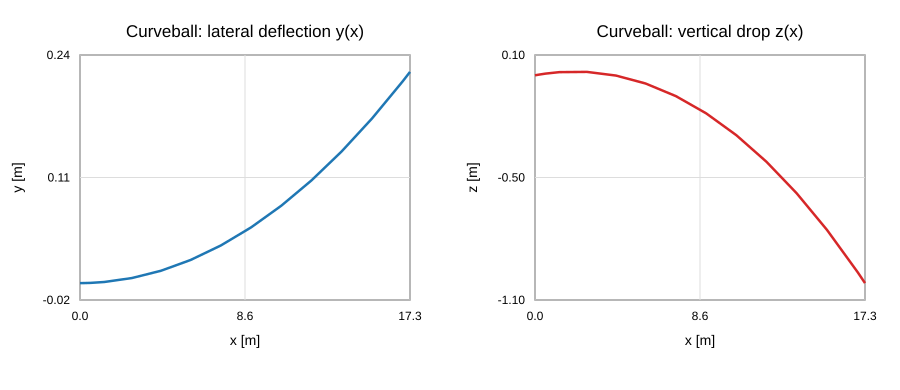

In [6]:
phi_curve = 0.7853981633974483
v0_curve  = 37.9984
f_curve   = lambda t, s: baseball_rhs(t, s, OMEGA, phi_curve)
y0_curve  = baseball_ic(v0_curve)
t_curve   = baseball_tend(v0_curve)

ts_c, ys_c, ns_c, nf_c = rk_adaptive(f_curve, 0.0, y0_curve, t_curve,
                                       1e-9, 4, return_trajectory=True)
xs_c  = ys_c[:, 0]
ysc_y = ys_c[:, 1]
zs_c  = ys_c[:, 2]

# Store reference final state for Part 6
ref_curve = ys_c[-1].copy()

print(f"Curveball: {ns_c} steps, {nf_c} f-calls")
print(f"Final: x={xs_c[-1]:.6f} m | y={ysc_y[-1]:.6f} m | z={zs_c[-1]:.6f} m")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(xs_c, ysc_y)
axes[0].set_xlabel('x [m]', fontsize=13)
axes[0].set_ylabel('y [m]', fontsize=13)
axes[0].set_title('Curveball: lateral deflection y(x)', fontsize=14)
axes[0].grid(True)

axes[1].plot(xs_c, zs_c)
axes[1].set_xlabel('x [m]', fontsize=13)
axes[1].set_ylabel('z [m]', fontsize=13)
axes[1].set_title('Curveball: vertical drop z(x)', fontsize=14)
axes[1].grid(True)

plt.tight_layout()
plt.show()

<div>

 The curveball ends at about $x=17.29\,\mathrm{m}$, $y=0.223\,\mathrm{m}$, and $z=-1.015\,\mathrm{m}$. The positive $y$ value shows the sideways deflection, and the negative $z$ value is the drop.

</div>

<div>

## Fastball Trajectory

For the fastball I use $v_0=42.47\,\mathrm{m/s}$, $\varphi=3.927\,\mathrm{rad}$, and the same spin rate. This is also solved with RK4 and tolerance $10^{-9}$.

The plots show $y(x)$ and $z(x)$, like in the curveball case.

</div>

Fastball: 14 steps, 168 f-calls
Final: x=17.466362 m | y=-0.202313 m | z=-0.373855 m


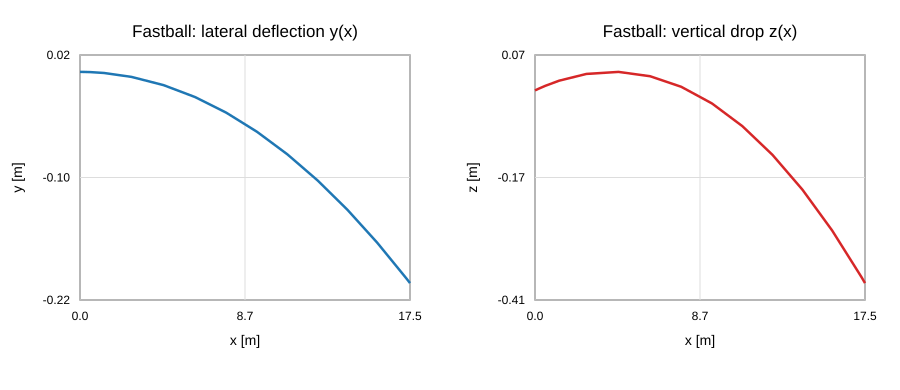

In [7]:
phi_fast = 3.9269908169872414
v0_fast  = 42.4688
f_fast   = lambda t, s: baseball_rhs(t, s, OMEGA, phi_fast)
y0_fast  = baseball_ic(v0_fast)
t_fast   = baseball_tend(v0_fast)

ts_f, ys_f, ns_f, nf_f = rk_adaptive(f_fast, 0.0, y0_fast, t_fast,
                                       1e-9, 4, return_trajectory=True)
xs_f  = ys_f[:, 0]
ysf_y = ys_f[:, 1]
zs_f  = ys_f[:, 2]

print(f"Fastball: {ns_f} steps, {nf_f} f-calls")
print(f"Final: x={xs_f[-1]:.6f} m | y={ysf_y[-1]:.6f} m | z={zs_f[-1]:.6f} m")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(xs_f, ysf_y)
axes[0].set_xlabel('x [m]', fontsize=13)
axes[0].set_ylabel('y [m]', fontsize=13)
axes[0].set_title('Fastball: lateral deflection y(x)', fontsize=14)
axes[0].grid(True)

axes[1].plot(xs_f, zs_f)
axes[1].set_xlabel('x [m]', fontsize=13)
axes[1].set_ylabel('z [m]', fontsize=13)
axes[1].grid(True)
axes[1].set_title('Fastball: vertical drop z(x)', fontsize=14)

plt.tight_layout()
plt.show()

<div>

 The fastball ends at about $x=17.47\,\mathrm{m}$, $y=-0.202\,\mathrm{m}$, and $z=-0.374\,\mathrm{m}$. The sideways deflection has the opposite sign from the curveball because the spin direction is different.

</div>

<div>

## Curveball Accuracy and Cost

Here I rerun the curveball with tolerances $10^{-1}$, $10^{-3}$, $10^{-5}$, and $10^{-7}$, for both RK3 and RK4.

The table gives the number of right-hand-side calls and the final-position differences from the accurate Part 4 result:
$$\Delta y=y_{\text{run}}(t_f)-y_{\text{ref}}(t_f),\quad
\Delta z=z_{\text{run}}(t_f)-z_{\text{ref}}(t_f).$$

</div>

In [8]:
ref_y = ref_curve[1]   # y position at high accuracy (Part 4)
ref_z = ref_curve[2]   # z position

print(f"{'Order':>7} {'Tol':>8} {'f-calls (baseball)':>20} {'Δy [m]':>14} {'Δz [m]':>14}")
print("-" * 67)
for order in (3, 4):
    for tol in (1e-1, 1e-3, 1e-5, 1e-7):
        y_fin, ns, nf = rk_adaptive(f_curve, 0.0, y0_curve, t_curve, tol, order)
        dy = y_fin[1] - ref_y
        dz = y_fin[2] - ref_z
        print(f"{order:>7} {tol:>8.0e} {nf:>20d} {dy:>14.4e} {dz:>14.4e}")

  Order      Tol   f-calls (baseball)         Δy [m]         Δz [m]
-------------------------------------------------------------------
      3    1e-01                   63     1.7257e-08    -1.2899e-07
      3    1e-03                   63     1.7257e-08    -1.2899e-07
      3    1e-05                   72     4.1948e-09    -3.1260e-08
      3    1e-07                  135     6.7305e-11    -4.6995e-10
      4    1e-01                   84     1.4455e-11     6.4250e-11
      4    1e-03                   84     1.4455e-11     6.4250e-11
      4    1e-05                   84     1.4455e-11     6.4250e-11
      4    1e-07                  108    -3.5291e-13     2.6924e-11


<div>

 All lower-accuracy curveball runs are very close to the high-accuracy result. RK4 is more efficient here: even with loose tolerance, its final $y$ and $z$ errors are around $10^{-11}$ to $10^{-10}\,\mathrm{m}$.

</div>